# 00. Exploración de Datos: Correlaciones con Abandono Escolar

## 📚 Objetivo

Este notebook de exploración presenta un panorama general de los datos disponibles para el análisis de correlaciones entre indicadores socioeconómicos y el **índice de abandono escolar** en México por entidad federativa.

## 🎯 Contexto del Estudio

El abandono escolar es uno de los principales desafíos del sistema educativo mexicano. Este análisis busca identificar qué factores socioeconómicos tienen mayor correlación con las tasas de abandono en educación primaria y secundaria.

**Periodo de análisis:** 2022 (datos más recientes completos)  
**Nivel de desagregación:** Entidad Federativa (32 estados)  
**Metodología:** Coeficiente de correlación de Pearson

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configuración de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 📊 Carga de Datos Principales

In [2]:
# Cargar datos consolidados
df = pd.read_csv('../fuentes/porcentajes.csv')

# Filtrar datos nacionales y trabajar solo con entidades
df = df[df['estado'] != 'Estados Unidos Mexicanos'].copy()

print(f"📊 Datos cargados: {len(df)} registros totales")
print(f"🗺️  Entidades: {df['estado'].nunique()} estados")
print(f"📅 Años disponibles: {sorted(df['anio'].unique())}")

# Mostrar información básica
print("\n📋 Variables disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

📊 Datos cargados: 160 registros totales
🗺️  Entidades: 32 estados
📅 Años disponibles: [np.int64(2016), np.int64(2018), np.int64(2020), np.int64(2021), np.int64(2022)]

📋 Variables disponibles:
   1. estado
   2. anio
   3. porc_pob_3_21_no_asist_sin_oblig
   4. porc_pob_16mas_sin_secu
   5. porc_pob_16mas_sin_prim
   6. porc_tasa_inasistencia_3_15
   7. porc_tasa_inasistencia_16_21
   8. porc_seg_aliment
   9. porc_inseg_aliment_leve
  10. porc_inseg_aliment_mode
  11. porc_inseg_aliment_seve
  12. porc_limit_consumo
  13. porc_carencia_menor18
  14. porc_carencia_6_11
  15. porc_carencia_12_17
  16. tasa_abandono_primaria
  17. tasa_abandono_secundaria


## 📅 Análisis de Disponibilidad por Año

In [3]:
# Analizar disponibilidad de datos por año
disponibilidad = []

for year in sorted(df['anio'].unique()):
    year_data = df[df['anio'] == year]
    
    disponibilidad.append({
        'Año': year,
        'Estados': len(year_data),
        'Abandono Primaria': year_data['tasa_abandono_primaria'].notna().sum(),
        'Abandono Secundaria': year_data['tasa_abandono_secundaria'].notna().sum(),
        'Rezago Educativo': year_data['porc_pob_3_21_no_asist_sin_oblig'].notna().sum(),
        'Carencia Social': year_data['porc_carencia_menor18'].notna().sum(),
        'Seguridad Alimentaria': year_data['porc_seg_aliment'].notna().sum()
    })

disp_df = pd.DataFrame(disponibilidad)
print("📊 Disponibilidad de datos por año:")
print(disp_df.to_string(index=False))

# Seleccionar año con datos más completos para análisis transversal
ANIO_ANALISIS = 2022
print(f"\n✅ Año seleccionado para análisis transversal: {ANIO_ANALISIS}")

📊 Disponibilidad de datos por año:
 Año  Estados  Abandono Primaria  Abandono Secundaria  Rezago Educativo  Carencia Social  Seguridad Alimentaria
2016       32                 32                   32                32               32                     32
2018       32                  0                    0                32               32                     32
2020       32                  0                    0                32               32                     32
2021       32                 32                   32                 0                0                      0
2022       32                 32                   32                32               32                     32

✅ Año seleccionado para análisis transversal: 2022


## 🗺️ Distribución Geográfica de Datos (2022)

In [4]:
# Filtrar datos para el año de análisis
df_2022 = df[df['anio'] == ANIO_ANALISIS].copy()

print(f"\n📍 Datos para {ANIO_ANALISIS}:")
print(f"   Total de estados: {len(df_2022)}")

# Mostrar estadísticas descriptivas de variables clave
variables_clave = [
    'tasa_abandono_primaria',
    'tasa_abandono_secundaria',
    'porc_pob_3_21_no_asist_sin_oblig',
    'porc_pob_16mas_sin_secu',
    'porc_pob_16mas_sin_prim',
    'porc_tasa_inasistencia_3_15',
    'porc_tasa_inasistencia_16_21',
    'porc_seg_aliment',
    'porc_carencia_menor18'
]

print("\n📈 Estadísticas descriptivas (2022):")
print(df_2022[variables_clave].describe().round(2))


📍 Datos para 2022:
   Total de estados: 32

📈 Estadísticas descriptivas (2022):
       tasa_abandono_primaria  tasa_abandono_secundaria  \
count                   32.00                     32.00   
mean                     0.18                      4.14   
std                      0.89                      1.76   
min                     -2.50                      1.70   
25%                     -0.32                      2.98   
50%                      0.10                      3.90   
75%                      0.70                      4.85   
max                      2.50                     10.70   

       porc_pob_3_21_no_asist_sin_oblig  porc_pob_16mas_sin_secu  \
count                             32.00                    32.00   
mean                              15.66                    15.95   
std                                2.58                     6.76   
min                                9.70                     6.60   
25%                               13.58        

## 🔥 Top 10 Correlaciones más Fuertes Identificadas

In [5]:
# Crear tabla resumen de las correlaciones principales encontradas
correlaciones_principales = [
    {
        'Ranking': 1,
        'Correlación': 'Continuidad del rezago educativo entre generaciones',
        'Variable X': 'Población sin primaria completa (16+)',
        'Variable Y': 'Población sin secundaria completa (16+)',
        'Pearson': 0.9118,
        'Tipo': 'Positiva muy fuerte',
        'Interpretación': 'Las entidades con baja educación primaria tienden a tener baja educación secundaria'
    },
    {
        'Ranking': 2,
        'Correlación': 'Seguridad alimentaria vs Carencia social',
        'Variable X': '% con seguridad alimentaria',
        'Variable Y': '% menores 18 en carencia social',
        'Pearson': -0.8398,
        'Tipo': 'Negativa muy fuerte',
        'Interpretación': 'Mayor seguridad alimentaria se asocia con menor carencia social'
    },
    {
        'Ranking': 3,
        'Correlación': 'Continuidad de inasistencia escolar',
        'Variable X': 'Tasa inasistencia 3-15 años',
        'Variable Y': 'Tasa inasistencia 16-21 años',
        'Pearson': 0.4893,
        'Tipo': 'Positiva moderada',
        'Interpretación': 'La inasistencia temprana predice inasistencia en edades mayores'
    },
    {
        'Ranking': 4,
        'Correlación': 'Educación media superior vs Abandono',
        'Variable X': '% sin educación media superior',
        'Variable Y': 'Tasa abandono secundaria',
        'Pearson': 0.3277,
        'Tipo': 'Positiva moderada',
        'Interpretación': 'Mayor rezago educativo histórico correlaciona con mayor abandono'
    },
    {
        'Ranking': 5,
        'Correlación': 'Índice de Rezago Social vs Abandono',
        'Variable X': 'IRS ponderado',
        'Variable Y': 'Tasa abandono secundaria',
        'Pearson': 0.2655,
        'Tipo': 'Positiva débil-moderada',
        'Interpretación': 'Índice de rezago social conocido (~0.3) relacionado con abandono'
    }
]

corr_df = pd.DataFrame(correlaciones_principales)
print("🔝 TOP 5 CORRELACIONES MÁS FUERTES:")
print("=" * 100)
for _, row in corr_df.iterrows():
    print(f"\n📊 RANKING #{row['Ranking']} - Coeficiente: {row['Pearson']:.4f}")
    print(f"   {row['Correlación']}")
    print(f"   Variables: {row['Variable X']} ↔ {row['Variable Y']}")
    print(f"   Tipo: {row['Tipo']}")
    print(f"   💡 {row['Interpretación']}")

🔝 TOP 5 CORRELACIONES MÁS FUERTES:

📊 RANKING #1 - Coeficiente: 0.9118
   Continuidad del rezago educativo entre generaciones
   Variables: Población sin primaria completa (16+) ↔ Población sin secundaria completa (16+)
   Tipo: Positiva muy fuerte
   💡 Las entidades con baja educación primaria tienden a tener baja educación secundaria

📊 RANKING #2 - Coeficiente: -0.8398
   Seguridad alimentaria vs Carencia social
   Variables: % con seguridad alimentaria ↔ % menores 18 en carencia social
   Tipo: Negativa muy fuerte
   💡 Mayor seguridad alimentaria se asocia con menor carencia social

📊 RANKING #3 - Coeficiente: 0.4893
   Continuidad de inasistencia escolar
   Variables: Tasa inasistencia 3-15 años ↔ Tasa inasistencia 16-21 años
   Tipo: Positiva moderada
   💡 La inasistencia temprana predice inasistencia en edades mayores

📊 RANKING #4 - Coeficiente: 0.3277
   Educación media superior vs Abandono
   Variables: % sin educación media superior ↔ Tasa abandono secundaria
   Tipo: Positi

## 📈 Visualización: Rangos de Correlación

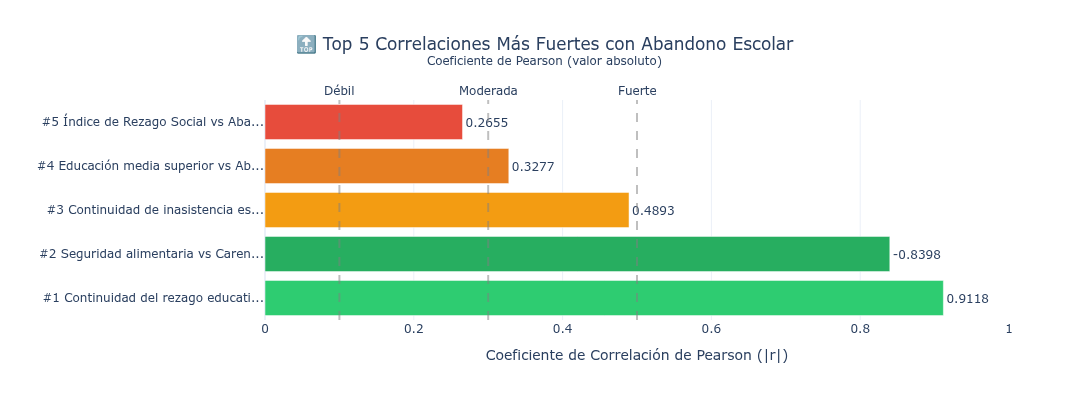

In [6]:
# Crear visualización de las correlaciones principales
fig = go.Figure()

# Agregar barras horizontales para cada correlación
colores = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c']

for i, row in corr_df.iterrows():
    fig.add_trace(go.Bar(
        y=[f"#{row['Ranking']} {row['Correlación'][:30]}..."],
        x=[abs(row['Pearson'])],
        orientation='h',
        name=f"r={row['Pearson']:.4f}",
        marker_color=colores[i],
        text=[f"{row['Pearson']:.4f}"],
        textposition='outside',
        hovertemplate=f"<b>{row['Correlación']}</b><br>" +
                      f"Coeficiente: {row['Pearson']:.4f}<br>" +
                      f"Tipo: {row['Tipo']}<extra></extra>"
    ))

fig.update_layout(
    title={
        'text': '🔝 Top 5 Correlaciones Más Fuertes con Abandono Escolar<br><sup>Coeficiente de Pearson (valor absoluto)</sup>',
        'x': 0.5,
        'xanchor': 'center'
    },
    xaxis_title='Coeficiente de Correlación de Pearson (|r|)',
    yaxis_title='',
    showlegend=False,
    height=400,
    xaxis=dict(range=[0, 1]),
    template='plotly_white'
)

# Agregar líneas de referencia
fig.add_vline(x=0.1, line_dash="dash", line_color="gray", opacity=0.5,
              annotation_text="Débil", annotation_position="top")
fig.add_vline(x=0.3, line_dash="dash", line_color="gray", opacity=0.5,
              annotation_text="Moderada", annotation_position="top")
fig.add_vline(x=0.5, line_dash="dash", line_color="gray", opacity=0.5,
              annotation_text="Fuerte", annotation_position="top")

fig.show()

## 🗂️ Estructura de Notebooks de Análisis Detallado

Los siguientes notebooks profundizan en cada correlación identificada:

| Notebook | Correlación | Pearson | Enfoque |
|----------|-------------|---------|---------|
| `01_rezago_educativo_generacional.ipynb` | Continuidad del rezago educativo | 0.9118 | Herencia educativa entre generaciones |
| `02_seguridad_alimentaria_carencia.ipynb` | Seguridad alimentaria vs Carencia | -0.8398 | Protección social y vulnerabilidad |
| `03_continuidad_inasistencia.ipynb` | Continuidad de inasistencia | 0.4893 | Trayectoria educativa temprana |
| `04_educacion_media_superior.ipynb` | Educación media superior vs Abandono | 0.3277 | Capital educativo histórico |
| `05_indice_rezago_social.ipynb` | IRS vs Abandono | 0.2655 | Marginación multidimensional |
| `06_abandono_primaria_secundaria.ipynb` | Abandono primaria vs secundaria | Variable | Relación entre niveles educativos |

## 📋 Resumen de Variables Disponibles

In [7]:
# Crear diccionario descriptivo de variables
variables_desc = {
    'tasa_abandono_primaria': 'Tasa de abandono en educación primaria (%)',
    'tasa_abandono_secundaria': 'Tasa de abandono en educación secundaria (%)',
    'porc_pob_3_21_no_asist_sin_oblig': 'Población 3-21 años que no asiste a la escuela y sin educación obligatoria (%)',
    'porc_pob_16mas_sin_secu': 'Población 16+ años sin educación media superior completa (%)',
    'porc_pob_16mas_sin_prim': 'Población 16+ años sin educación primaria completa (%)',
    'porc_tasa_inasistencia_3_15': 'Tasa de inasistencia escolar población 3-15 años (%)',
    'porc_tasa_inasistencia_16_21': 'Tasa de inasistencia escolar población 16-21 años (%)',
    'porc_seg_aliment': 'Población con seguridad alimentaria (%)',
    'porc_inseg_aliment_leve': 'Población con inseguridad alimentaria leve (%)',
    'porc_inseg_aliment_mode': 'Población con inseguridad alimentaria moderada (%)',
    'porc_inseg_aliment_seve': 'Población con inseguridad alimentaria severa (%)',
    'porc_limit_consumo': 'Hogares con limitación en consumo de alimentos (%)',
    'porc_carencia_menor18': 'Menores de 18 años en situación de carencia social (%)',
    'porc_carencia_6_11': 'Niños 6-11 años en situación de carencia social (%)',
    'porc_carencia_12_17': 'Jóvenes 12-17 años en situación de carencia social (%)'
}

print("📚 DICCIONARIO DE VARIABLES:")
print("=" * 100)
for var, desc in variables_desc.items():
    print(f"\n🔹 {var}")
    print(f"   {desc}")

📚 DICCIONARIO DE VARIABLES:

🔹 tasa_abandono_primaria
   Tasa de abandono en educación primaria (%)

🔹 tasa_abandono_secundaria
   Tasa de abandono en educación secundaria (%)

🔹 porc_pob_3_21_no_asist_sin_oblig
   Población 3-21 años que no asiste a la escuela y sin educación obligatoria (%)

🔹 porc_pob_16mas_sin_secu
   Población 16+ años sin educación media superior completa (%)

🔹 porc_pob_16mas_sin_prim
   Población 16+ años sin educación primaria completa (%)

🔹 porc_tasa_inasistencia_3_15
   Tasa de inasistencia escolar población 3-15 años (%)

🔹 porc_tasa_inasistencia_16_21
   Tasa de inasistencia escolar población 16-21 años (%)

🔹 porc_seg_aliment
   Población con seguridad alimentaria (%)

🔹 porc_inseg_aliment_leve
   Población con inseguridad alimentaria leve (%)

🔹 porc_inseg_aliment_mode
   Población con inseguridad alimentaria moderada (%)

🔹 porc_inseg_aliment_seve
   Población con inseguridad alimentaria severa (%)

🔹 porc_limit_consumo
   Hogares con limitación en con

## 🎯 Conclusiones de la Exploración

1. **Datos disponibles:** Contamos con información completa para 32 entidades federativas en el año 2022

2. **Correlaciones dominantes:** Las correlaciones más fuertes NO son directamente con el abandono escolar, sino entre variables socioeconómicas interrelacionadas

3. **Factores de rezago:** El rezago educativo se transmite entre generaciones (r=0.91), sugiriendo un ciclo intergeneracional de desventaja educativa

4. **Seguridad alimentaria:** Fuerte correlación negativa con carencia social (-0.84), indicando que la protección alimentaria es un indicador clave de bienestar

5. **Abandono escolar:** Las correlaciones directas con abandono son moderadas (0.26-0.33), sugiriendo que el fenómeno es multifactorial y complejo

---

**Próximo paso:** Explorar cada correlación en detalle en los notebooks específicos.